# Exploratory Data Analysis (EDA)
## Iranian Telecom Churn Dataset

This notebook analyzes the distribution of each column in the dataset to determine the appropriate transformation method:
- **MinMaxScaler**: For columns with uniform distribution (bounded values)
- **StandardScaler**: For columns with normal/Gaussian distribution
- **PowerTransformer**: For columns with skewed distribution (makes data more Gaussian-like)

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split
import os

# Set paths
BASE_PATH = r"C:\Users\Administrator\Documents\Data_Science__Projects\Iranian_Telecom_Churn"
DATA_RAW = os.path.join(BASE_PATH, "data", "raw", "Customer Churn.csv")

# Load data
data = pd.read_csv(DATA_RAW)
print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
data.head()

Dataset shape: (3150, 14)

Columns: ['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


## 1. Dataset Overview

In [2]:
# Basic info
print("Dataset Info:")
print("-" * 50)
data.info()
print("\n" + "-" * 50)
print("\nStatistical Summary:")
data.describe()

Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn        

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


## 2. Column Distributions Analysis

Let's visualize the distribution of each column to determine the appropriate scaler:
- **Uniform distribution** → MinMaxScaler
- **Normal/Gaussian distribution** → StandardScaler  
- **Skewed distribution** → PowerTransformer (Yeo-Johnson)

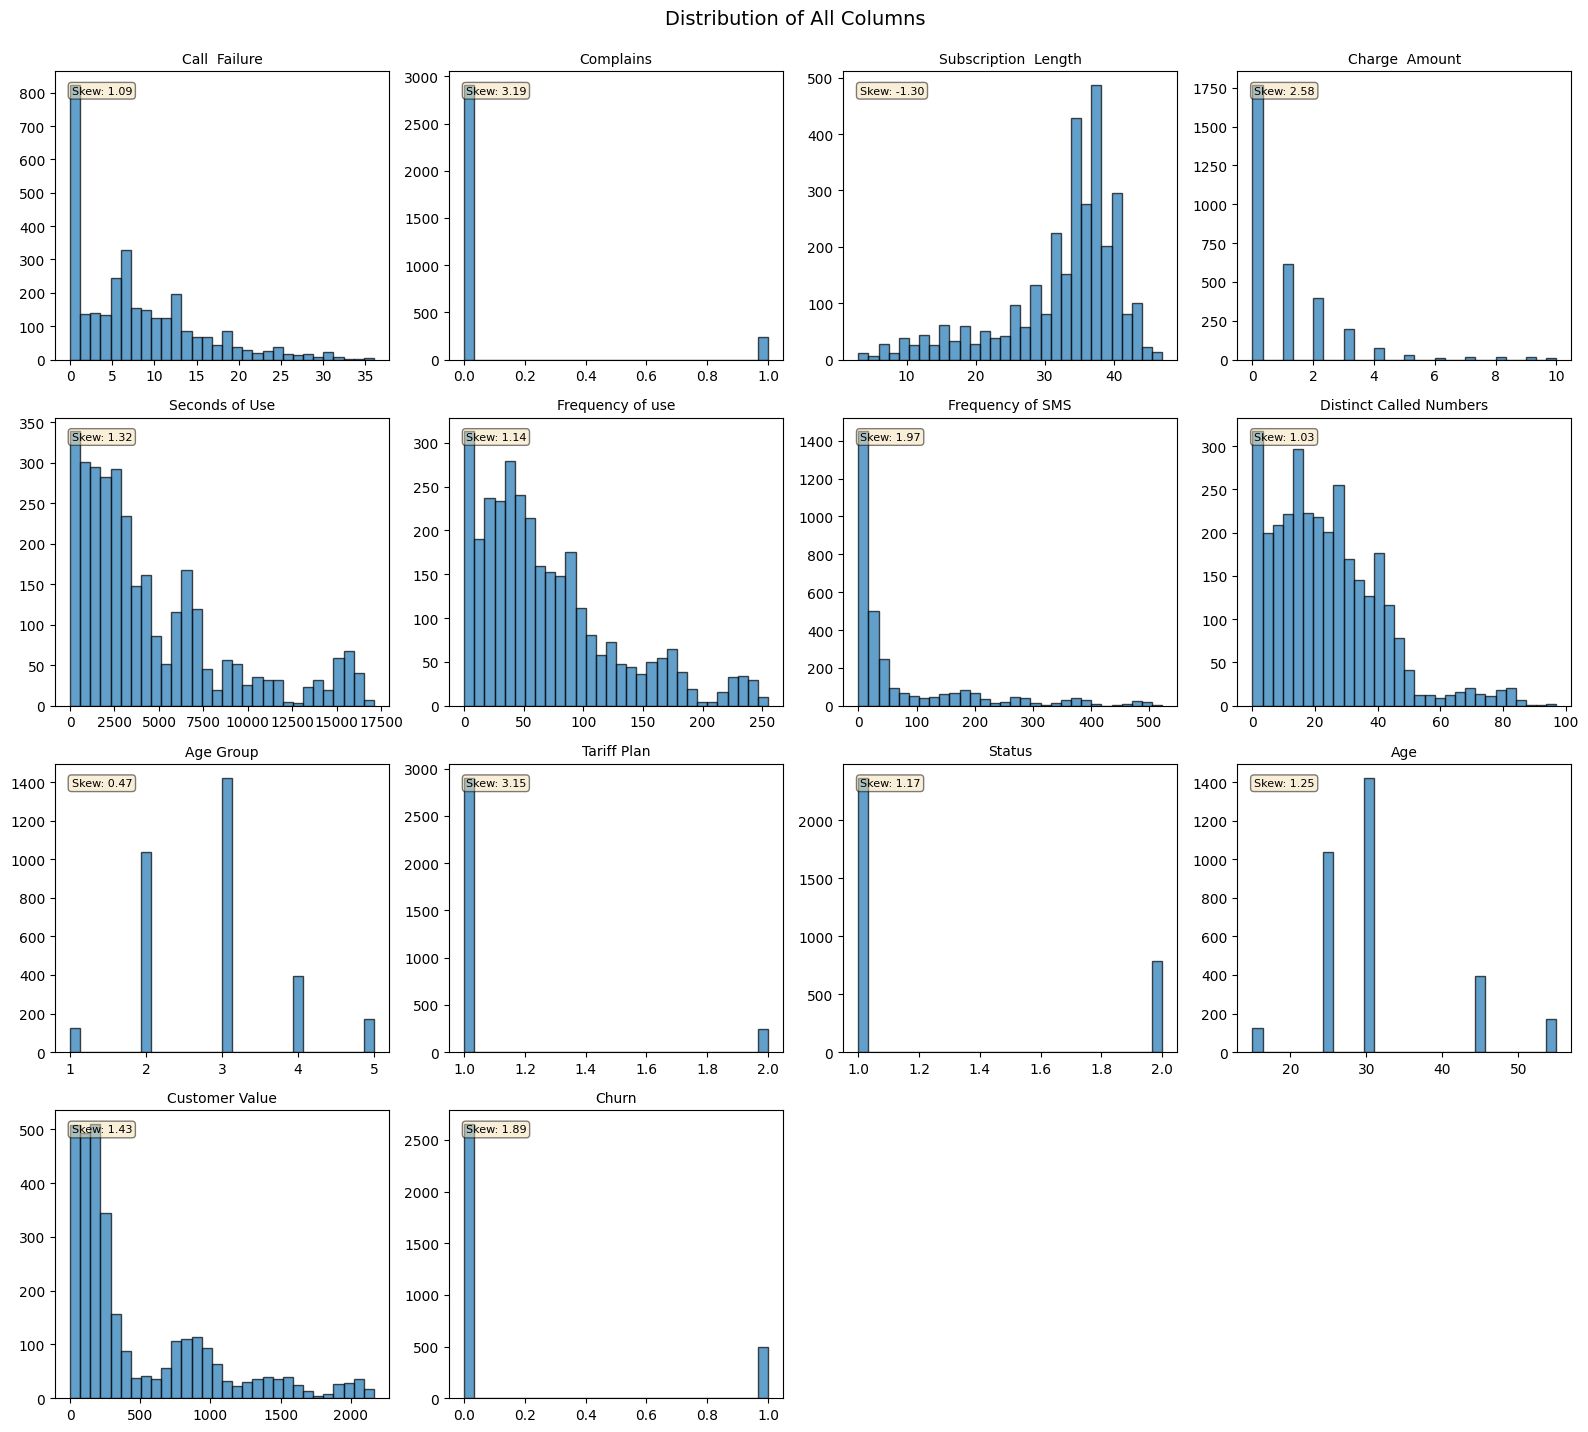

In [3]:
# Analyze each column's distribution
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(data.columns):
    ax = axes[idx]
    ax.hist(data[col], bins=30, edgecolor='black', alpha=0.7)
    ax.set_title(f'{col}', fontsize=10)
    ax.set_xlabel('')
    
    # Calculate skewness
    skew = data[col].skew()
    ax.annotate(f'Skew: {skew:.2f}', xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=8, verticalalignment='top', 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Hide empty subplots
for idx in range(len(data.columns), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.suptitle('Distribution of All Columns', fontsize=14, y=1.02)
plt.show()

## 3. Detailed Distribution Analysis by Column Type

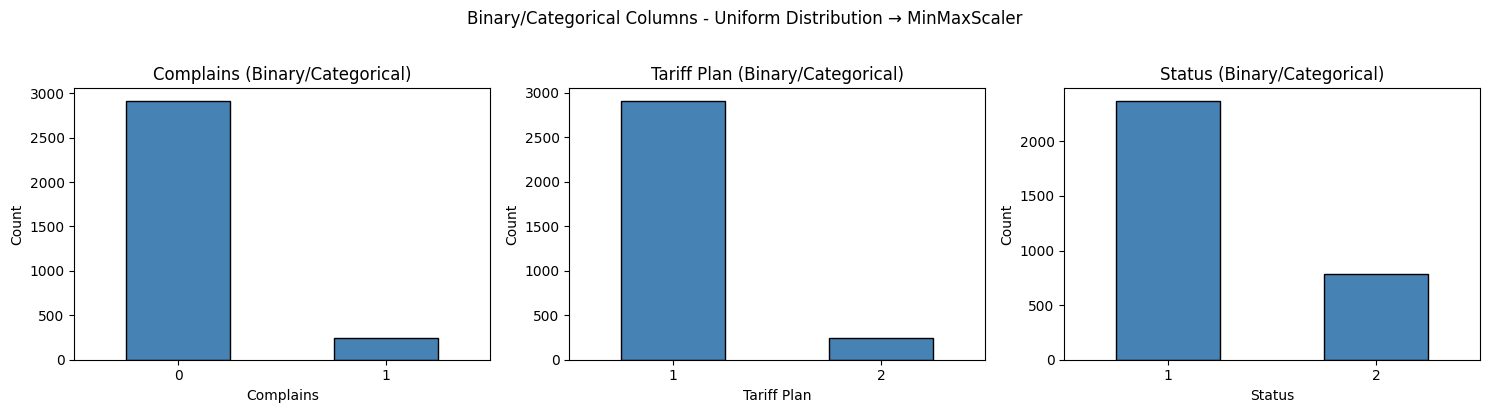

→ These columns have categorical/binary values → Use MinMaxScaler


In [4]:
# Categorical/Binary columns - likely uniform distribution
categorical_cols = ['Complains', 'Tariff Plan', 'Status']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, col in enumerate(categorical_cols):
    data[col].value_counts().plot(kind='bar', ax=axes[idx], color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{col} (Binary/Categorical)')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=0)

plt.suptitle('Binary/Categorical Columns - Uniform Distribution → MinMaxScaler', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("→ These columns have categorical/binary values → Use MinMaxScaler")

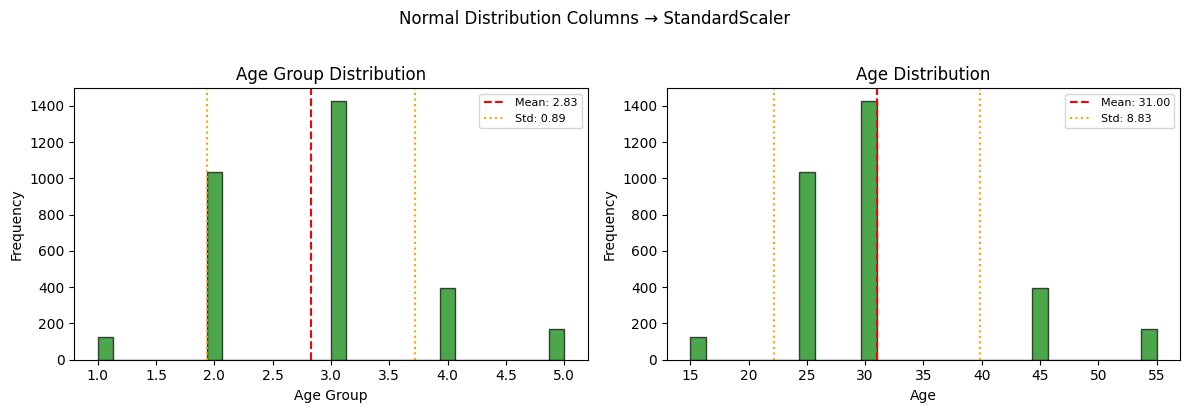

→ These columns follow a normal distribution → Use StandardScaler


In [5]:
# Columns that appear to have normal distribution - StandardScaler
normal_cols = ['Age Group', 'Age']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for idx, col in enumerate(normal_cols):
    axes[idx].hist(data[col], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    
    # Add statistics
    mean_val = data[col].mean()
    std_val = data[col].std()
    axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[idx].axvline(mean_val + std_val, color='orange', linestyle=':', label=f'Std: {std_val:.2f}')
    axes[idx].axvline(mean_val - std_val, color='orange', linestyle=':')
    axes[idx].legend(fontsize=8)

plt.suptitle('Normal Distribution Columns → StandardScaler', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("→ These columns follow a normal distribution → Use StandardScaler")

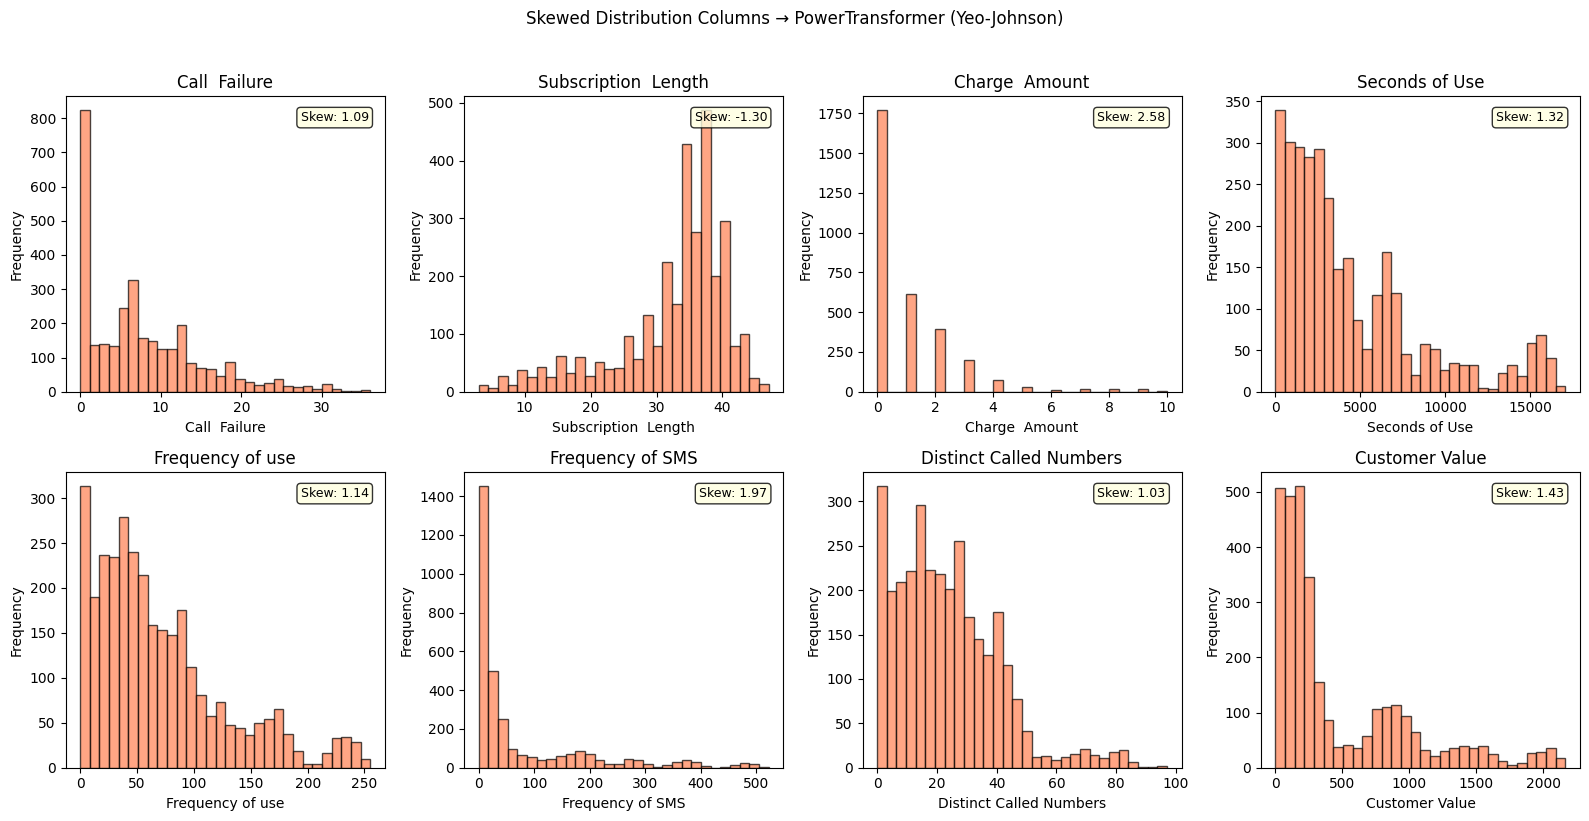

→ These columns are right-skewed → Use PowerTransformer


In [6]:
# Columns with skewed distribution - PowerTransformer
skewed_cols = ['Call  Failure', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 
               'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Customer Value']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(skewed_cols):
    axes[idx].hist(data[col], bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    
    # Add skewness value
    skew = data[col].skew()
    axes[idx].annotate(f'Skew: {skew:.2f}', xy=(0.95, 0.95), xycoords='axes fraction',
                       fontsize=9, verticalalignment='top', horizontalalignment='right',
                       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Skewed Distribution Columns → PowerTransformer (Yeo-Johnson)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("→ These columns are right-skewed → Use PowerTransformer")

## 4. Target Variable Distribution

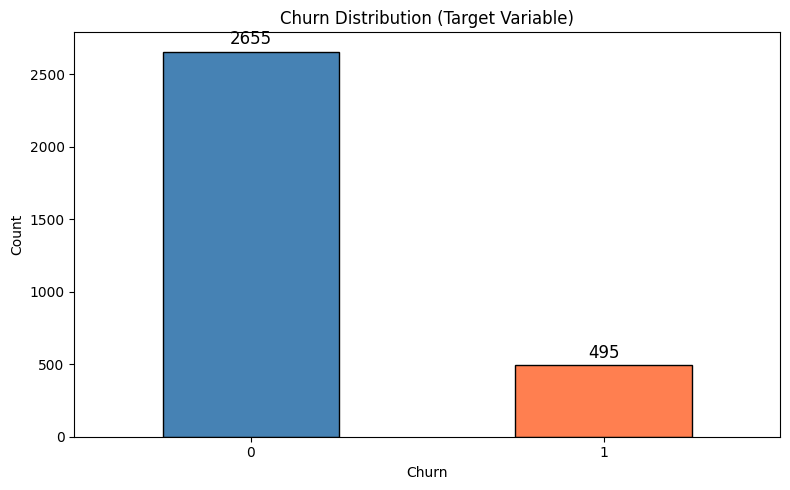


Churn distribution:
Churn
0    2655
1     495
Name: count, dtype: int64

Churn rate: 15.71%


In [7]:
# Target variable (Churn)
fig, ax = plt.subplots(figsize=(8, 5))
data['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black', ax=ax)
ax.set_title('Churn Distribution (Target Variable)')
ax.set_xlabel('Churn')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)

# Add value labels
for i, v in enumerate(data['Churn'].value_counts()):
    ax.text(i, v + 50, str(v), ha='center', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nChurn distribution:\n{data['Churn'].value_counts()}")
print(f"\nChurn rate: {data['Churn'].mean()*100:.2f}%")

## 5. Summary: Recommended Transformations

In [8]:
# Summary table
print("=" * 70)
print("TRANSFORMATION SUMMARY")
print("=" * 70)

print("\n📊 MinMaxScaler (Uniform/Binary distribution):")
for col in categorical_cols:
    print(f"   - {col}")

print("\n📊 StandardScaler (Normal/Gaussian distribution):")
for col in normal_cols:
    print(f"   - {col}")

print("\n📊 PowerTransformer (Skewed distribution):")
for col in skewed_cols:
    print(f"   - {col}")

print("\n" + "=" * 70)
print("Target Variable:")
print(f"   - Churn (binary classification)")
print("=" * 70)

TRANSFORMATION SUMMARY

📊 MinMaxScaler (Uniform/Binary distribution):
   - Complains
   - Tariff Plan
   - Status

📊 StandardScaler (Normal/Gaussian distribution):
   - Age Group
   - Age

📊 PowerTransformer (Skewed distribution):
   - Call  Failure
   - Subscription  Length
   - Charge  Amount
   - Seconds of Use
   - Frequency of use
   - Frequency of SMS
   - Distinct Called Numbers
   - Customer Value

Target Variable:
   - Churn (binary classification)


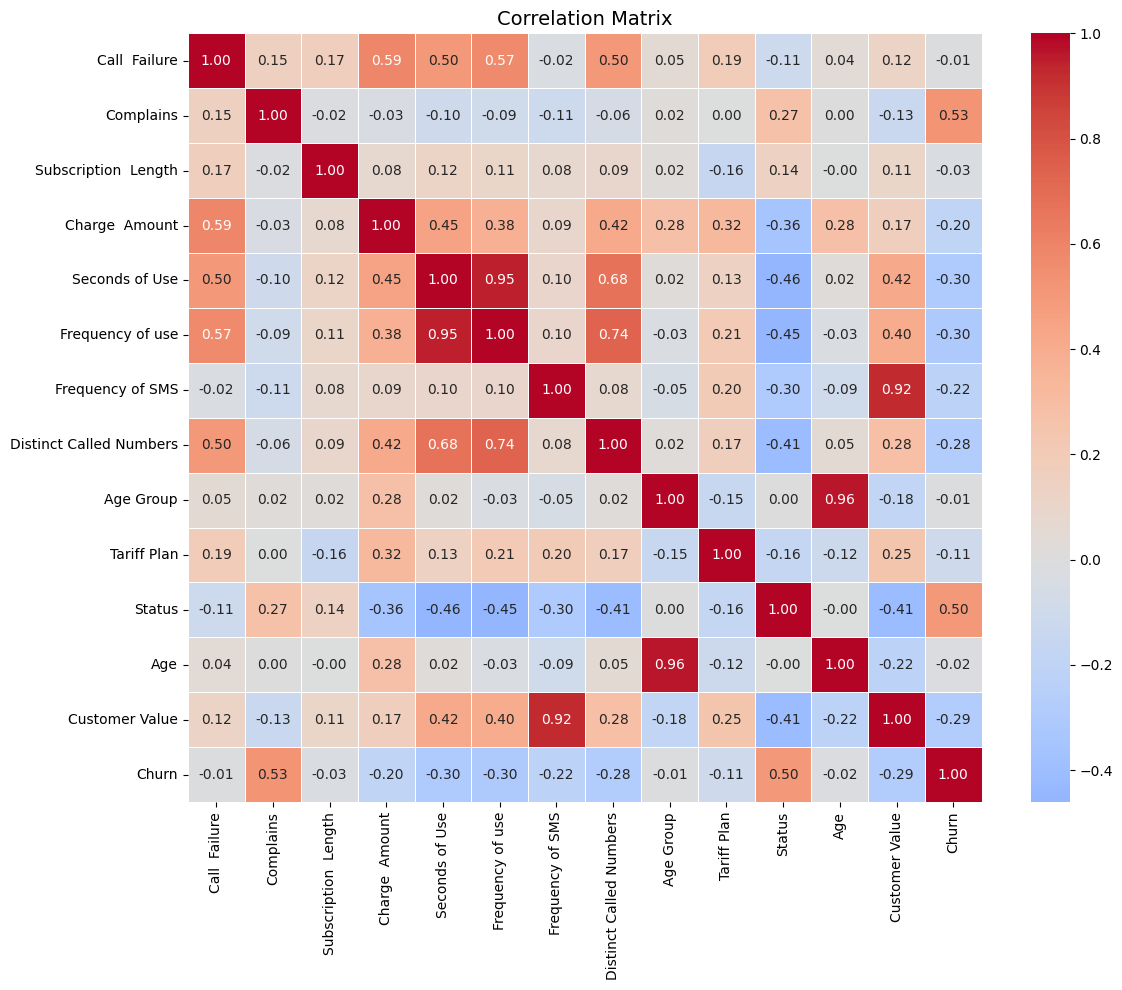


Correlation with Churn:
Complains                  0.532053
Status                     0.498976
Call  Failure             -0.008987
Age Group                 -0.014550
Age                       -0.017705
Subscription  Length      -0.032588
Tariff Plan               -0.105853
Charge  Amount            -0.202305
Frequency of SMS          -0.220754
Distinct Called Numbers   -0.278867
Customer Value            -0.289144
Seconds of Use            -0.298935
Frequency of use          -0.303337
Name: Churn, dtype: float64


In [9]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

# Show correlations with target
print("\nCorrelation with Churn:")
churn_corr = correlation_matrix['Churn'].drop('Churn').sort_values(ascending=False)
print(churn_corr)